In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
import seaborn as sns

In [6]:
# Configuración general de visualización
sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [7]:
# Cargar el dataset
df = pd.read_csv('netflix_titles.csv')

In [27]:
# Mostrar las primeras filas
print('Primeras filas del dataset')
df.head()

= Primeras filas del dataset =


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [28]:
# Mostrar las dimensiones
df.shape

(8807, 12)

In [29]:
# Mostrar los nombres de columnas
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [30]:
# Mostrar tipos de datos
df.dtypes

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

In [31]:
# Identificar valores nulos
df.isnull().sum() 

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [32]:
# Calcular porcentaje de valores faltantes
porcentaje_nulos = (df.isnull().sum() / len(df)) * 100
porcentaje_nulos

show_id          0.000000
type             0.000000
title            0.000000
director        29.908028
cast             9.367549
country          9.435676
date_added       0.113546
release_year     0.000000
rating           0.045418
duration         0.034064
listed_in        0.000000
description      0.000000
dtype: float64

In [33]:
# Detectar registros duplicados
df.duplicated().sum()

np.int64(0)

In [16]:
# Aplicar estrategias de limpieza: eliminación y transformación
df_limpio = df.copy()

In [17]:
# Eliminar duplicados
df_limpio.drop_duplicates(inplace=True)

In [34]:
# Rellenar nulos en columnas categóricas
df_limpio['director'] = df_limpio['director'].fillna('Desconocido')
df_limpio['cast'] = df_limpio['cast'].fillna('Desconocido')
df_limpio['country'] = df_limpio['country'].fillna('Desconocido')

In [35]:
# Eliminar filas donde date_added o rating sean nulos
df_limpio.dropna(subset=['date_added', 'rating'], inplace=True)

In [39]:

# Convertir date_added a datetime y extraer año y mes
df_limpio['date_added'] = pd.to_datetime(df_limpio['date_added'])
df_limpio['year_added'] = df_limpio['date_added'].dt.year
df_limpio['month_added'] = df_limpio['date_added'].dt.month


In [40]:

df_limpio.shape

(8793, 14)

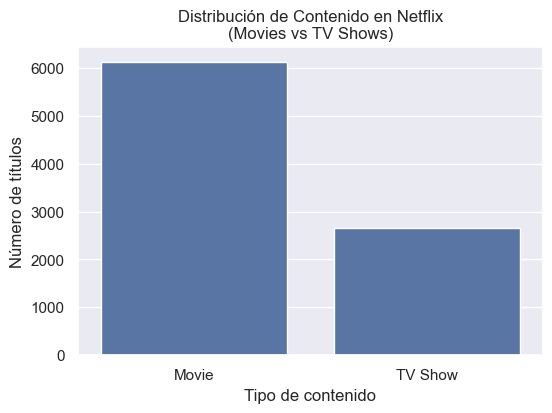

In [50]:
# Gráfica 1: Distribución de tipo de contenido (Movie vs TV Show)
plt.figure(figsize=(6, 4))
sns.countplot(df_limpio, x='type')
plt.title('Distribución de Contenido en Netflix\n(Movies vs TV Shows)')
plt.xlabel('Tipo de contenido')
plt.ylabel('Número de títulos')
plt.show()

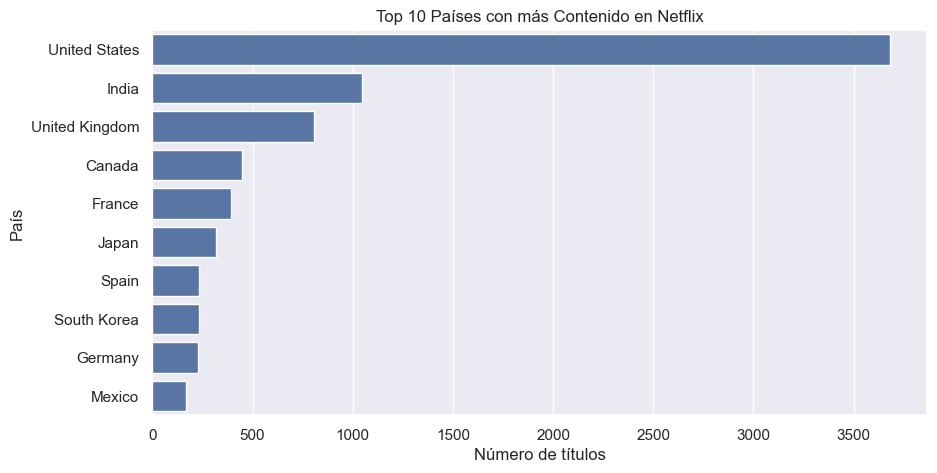

In [51]:
# Gráfica 2: Top 10 países con más contenido
plt.figure(figsize=(10, 5))
top_paises = (df_limpio[df_limpio['country'] != 'Desconocido']['country']
              .str.split(',').explode().str.strip()
              .value_counts().head(10))
sns.barplot(x=top_paises.values, y=top_paises.index)
plt.title('Top 10 Países con más Contenido en Netflix')
plt.xlabel('Número de títulos')
plt.ylabel('País')
plt.show()

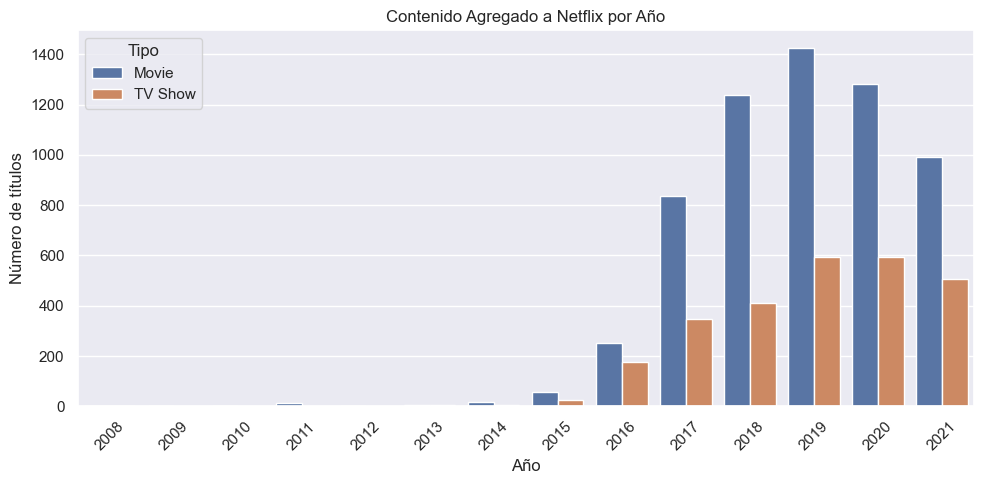

In [52]:
# Gráfica 3: Contenido agregado por año
plt.figure(figsize=(10, 5))
sns.countplot(df_limpio, x='year_added', hue='type')
plt.title('Contenido Agregado a Netflix por Año')
plt.xlabel('Año')
plt.ylabel('Número de títulos')
plt.xticks(rotation=45)
plt.legend(title='Tipo')
plt.tight_layout()
plt.show()

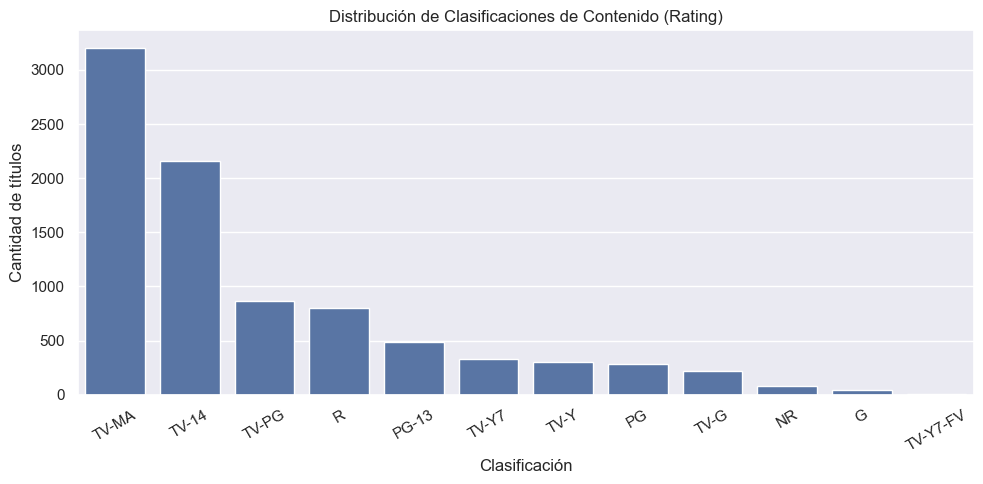

In [53]:
# Gráfica 4: Distribución de clasificaciones (rating)
plt.figure(figsize=(10, 5))
sns.countplot(df_limpio, x='rating', order=df_limpio['rating'].value_counts().index[:12])
plt.title('Distribución de Clasificaciones de Contenido (Rating)')
plt.xlabel('Clasificación')
plt.ylabel('Cantidad de títulos')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [45]:
# Estadísticas de apoyo
df_limpio['type'].value_counts(normalize=True) * 100

type
Movie      69.703173
TV Show    30.296827
Name: proportion, dtype: float64

In [46]:
contenido_por_anio.sum(axis=1).idxmax()

np.int32(2019)

In [47]:
df_limpio['rating'].value_counts().head(3)

rating
TV-MA    3205
TV-14    2157
TV-PG     861
Name: count, dtype: int64

In [ ]:
## Conclusiones — Capa de Conocimiento
Conclusión 1
Netflix tiene más películas que series de TV, lo que muestra que la plataforma ha priorizado el contenido cinematográfico.

Conclusión 2
El catálogo creció considerablemente con el paso del tiempo, reflejando la expansión de Netflix y su inversión en contenido propio.

Conclusión 3
Estados Unidos es el país con más títulos, seguido por India y el Reino Unido, lo que muestra que el contenido en inglés domina la plataforma.